In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

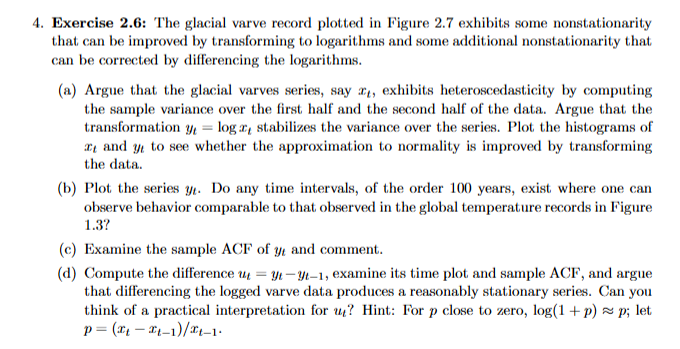

(A)

In [10]:
df = pd.read_csv("varve.csv")
n = len(df)
var1 = np.var(df['value'][0:n//2])
var2 = np.var(df['value'][n//2:])
print(f"Variance of the first half of the sample = {var1:.2f}")
print(f"Variance of the second half of the sample = {var2:.2f}")

Variance of the first half of the sample = 133.04
Variance of the second half of the sample = 592.62


In [11]:
df['log value'] = np.log(df['value'])
var1 = np.var(df['log value'][0:n//2])
var2 = np.var(df['log value'][n//2:])
print(f"Variance of the first half of the sample when log transformed = {var1:.2f}")
print(f"Variance of the second half of the sample when log transformed = {var2:.2f}")

Variance of the first half of the sample when log transformed = 0.27
Variance of the second half of the sample when log transformed = 0.45


<Axes: xlabel='log value', ylabel='Count'>

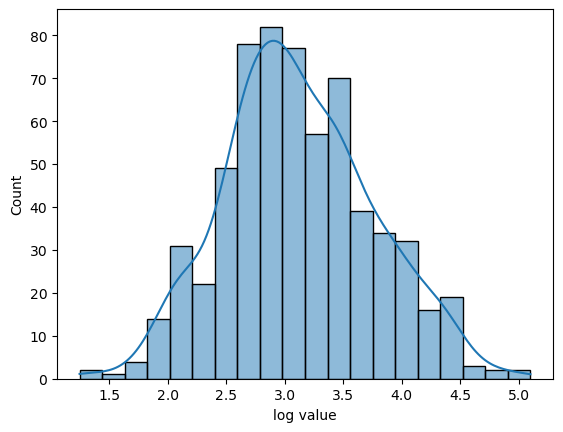

In [12]:
sns.histplot(data=df, x=df['log value'], kde=True)

<Axes: xlabel='log value', ylabel='Count'>

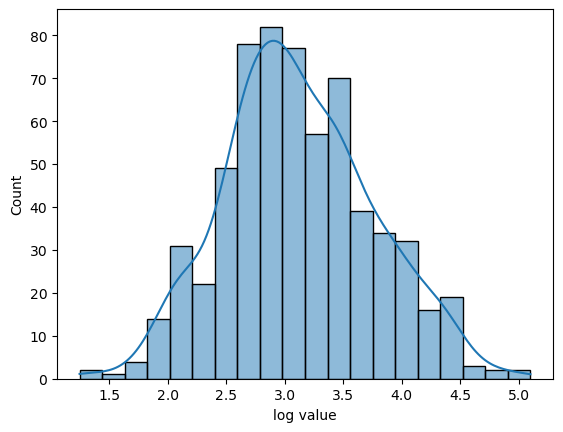

In [13]:
sns.histplot(data=df, x=df['log value'], kde=True)

(B)

<Figure size 1400x600 with 0 Axes>

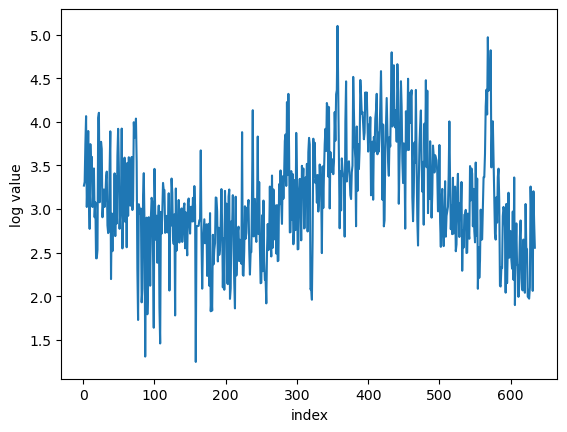

<Figure size 1400x600 with 0 Axes>

In [14]:
sns.lineplot(x=df['index'], y=df['log value'])
plt.figure(figsize=(14,6))

Yes, between year 250 and 350 there appears to be a spike similar to that in 1.3 signifying a warming period.

(C)

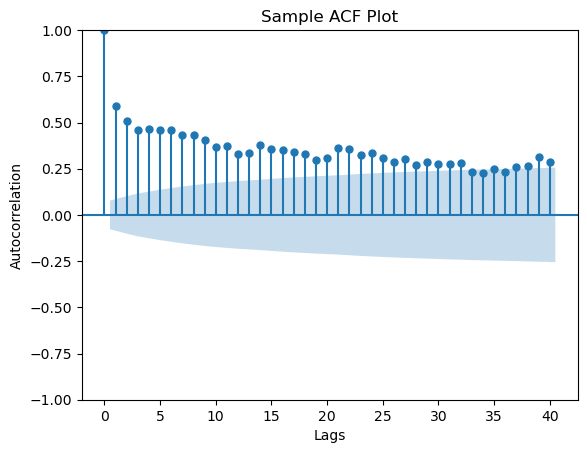

In [16]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df["log value"], lags=40)
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.title("Sample ACF Plot")
plt.show()

Clearly a non-stationary time series due to the high autocorrelation that does not go to zero even all the way out to lag 40. If this was a stationary system, we would expect certain lags to have a positive value but decay to zero at a reasonable pace.

(D)

In [17]:
df['difference'] = df['log value'].diff()
dfNoNa = df.dropna()

<Axes: xlabel='index', ylabel='difference'>

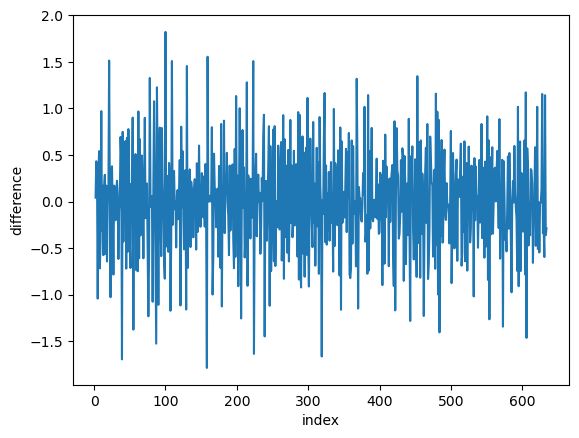

In [18]:
sns.lineplot(x=df['index'], y=dfNoNa['difference'])

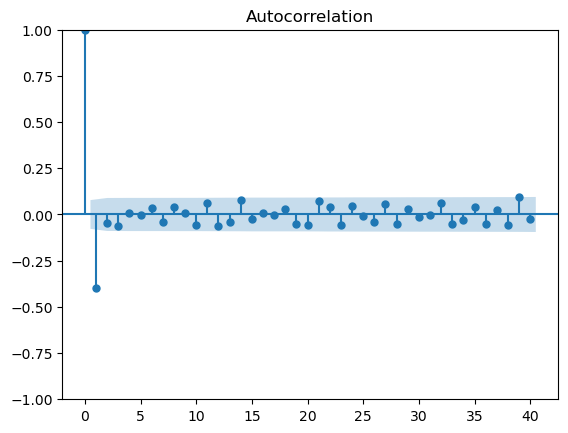

In [19]:
plot_acf(dfNoNa['difference'], lags = 40)
plt.show()

Clearly a much more stationary system: time series looks like white noise and ACF plot sees little auto correlation except for the first few lags but returns to zero.

Practical interpretation: By the properties of the natural log, the difference of the natural log of the varve data is approximately equal to the percentage change with an increase in 1 on the index.